# Laboratorio 3 – Aprendizaje de máquina  
## Recomendación de planes personalizados para SmartAlpes

### Integrantes:

1. Juan Sebastian Rodriguez Torres - 202214617 - js.rodriguezt1@uniandes.edu.co  
2. Luis Felipe Sales Galviz - 202211531 - l.sales@uniandes.edu.co 

---

Aqui desarrollaremos un sistema de recomendación de planes de entrenamiento y nutrición para los usuarios de SmartAlpes.
Como el número de usuarios aumenta se ha recopilado información sobre los clientes paracrear modelos para generar recomendaciones personalizadas de manera consistente.

Vamos a desarrollar y comparar los 4 modelos de clasificación que permitan predecir:

- Un plan de entrenamiento recomendado (Uno creado con Regresión logística y otro con árbol de decisión).
- Un plan de nutrición recomendado. (Uno creado con Regresión logística y otro con árbol de decisión).

# 1. Carga de datos

Los datos utilizados en este laboratorio contienen información demográfica, física y de estilo de vida de los usuarios, junto con las recomendaciones de planes de entrenamiento y nutrición que ya se habian asignado a los usuarios.

Ahora procedemos a cargar el dataset principal y visualizar sus primeras filas.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

df_real = pd.read_csv("./data/Datos_Laboratorio3.csv", sep=";", encoding="latin1")
df = df_real.copy()
df.head(8)

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan
5,32,Masculino,134.8,1.61,52.00,Perdida grasa,Ninguno,Moderado,Avanzado,Pescetariano,...,1,6.1,0,0.0,0.22,152.4,7525,1.34,Medio,Balanceado
6,34,Femenino,101.9,2.05,24.25,General,Hipertension,Alto,Intermedio,Pescetariano,...,0,0.0,0,0.0,0.51,205.6,11066,1.52,Bajo,Sin plan
7,57,Femenino,120.6,1.72,40.77,Ganancia muscular,Lesion,Moderado,Intermedio,No-Vegetariano,...,0,0.0,1,16.6,0.79,54.9,10772,2.23,Bajo,Especializado


# 2. Exploración y análisis de los datos

En esta sección se realiza una exploración del dataset para comprender su estructura y las características de los datos, y tambien identificar posibles problemas de calidad en los datos que deban ser modificados para un correcto uso.

Queremos identificar:
- Número de filas y columnas.
- Tipos de variables presentes.
- Distribución general de los datos.
- Valores faltantes.
- Registros duplicados.
- Distribución de variables numéricas.
- Distribución de variables categóricas.
- Presencia de valores atípicos (outliers).
- Balance de clases en las variables objetivo.

In [11]:
print("\n\n◉ INFORMACION DEL DATAFRAME (NO NULOS Y TIPOS DE DATOS):\n")
df.info()



◉ INFORMACION DEL DATAFRAME (NO NULOS Y TIPOS DE DATOS):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Gnereo                   9698 non-null   object 
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   object 
 6   Condicion_salud          9698 non-null   object 
 7   Nivel_Actividad          9698 non-null   object 
 8   Nivel_experiencia        9698 non-null   object 
 9   Dieta_preferida          9698 non-null   object 
 10  Horas_sueño              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   object 
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible 

In [12]:
print("\n\n◉ DESCRIPCIÓN ESTADÍSTICA - VARIABLES NUMÉRICAS:\n")
df.describe()



◉ DESCRIPCIÓN ESTADÍSTICA - VARIABLES NUMÉRICAS:



,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


In [9]:
print("◉ (EXPLORACIÓN) QUÉ PASA SI ELIMINAMOS TODOS LOS REGISTROS CON DATOS NULOS:")
print("Tamaño antes:", df.shape)
df_prueba1 = df.dropna()
print("Tamaño después:", df_prueba1.shape)


◉ (EXPLORACIÓN) QUÉ PASA SI ELIMINAMOS TODOS LOS REGISTROS CON DATOS NULOS:
Tamaño antes: (9698, 26)
Tamaño después: (9687, 26)


In [19]:
total_duplicados = df.duplicated().sum()
print("\n◉ CANTIDAD DE REGISTROS DUPLICADOS: " + str(total_duplicados))


◉ CANTIDAD DE REGISTROS DUPLICADOS: 0




◉ HEATMAP PARA VER CORRELACIÓN ENTRE VARIABLES:



<Axes: >

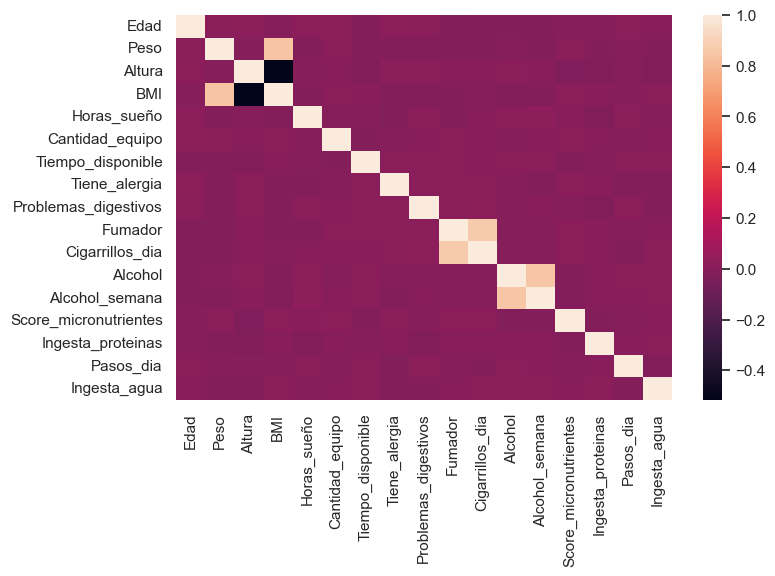

In [13]:
print("\n\n◉ HEATMAP PARA VER CORRELACIÓN ENTRE VARIABLES:\n")
sns.heatmap(df.corr(numeric_only=True))

In [33]:
print("\n\n◉ VERIFICAR VARIABLES CATEGORICAS:\n")

categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    print("\nVariable:", col)
    print(df[col].value_counts())



◉ VERIFICAR VARIABLES CATEGORICAS:


Variable: Gnereo
Gnereo
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64

Variable: Objetivo
Objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64

Variable: Condicion_salud
Condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64

Variable: Nivel_Actividad
Nivel_Actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64

Variable: Nivel_experiencia
Nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64

Variable: Dieta_preferida
Dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11




◉ VERIFICAR OUTLIERS:



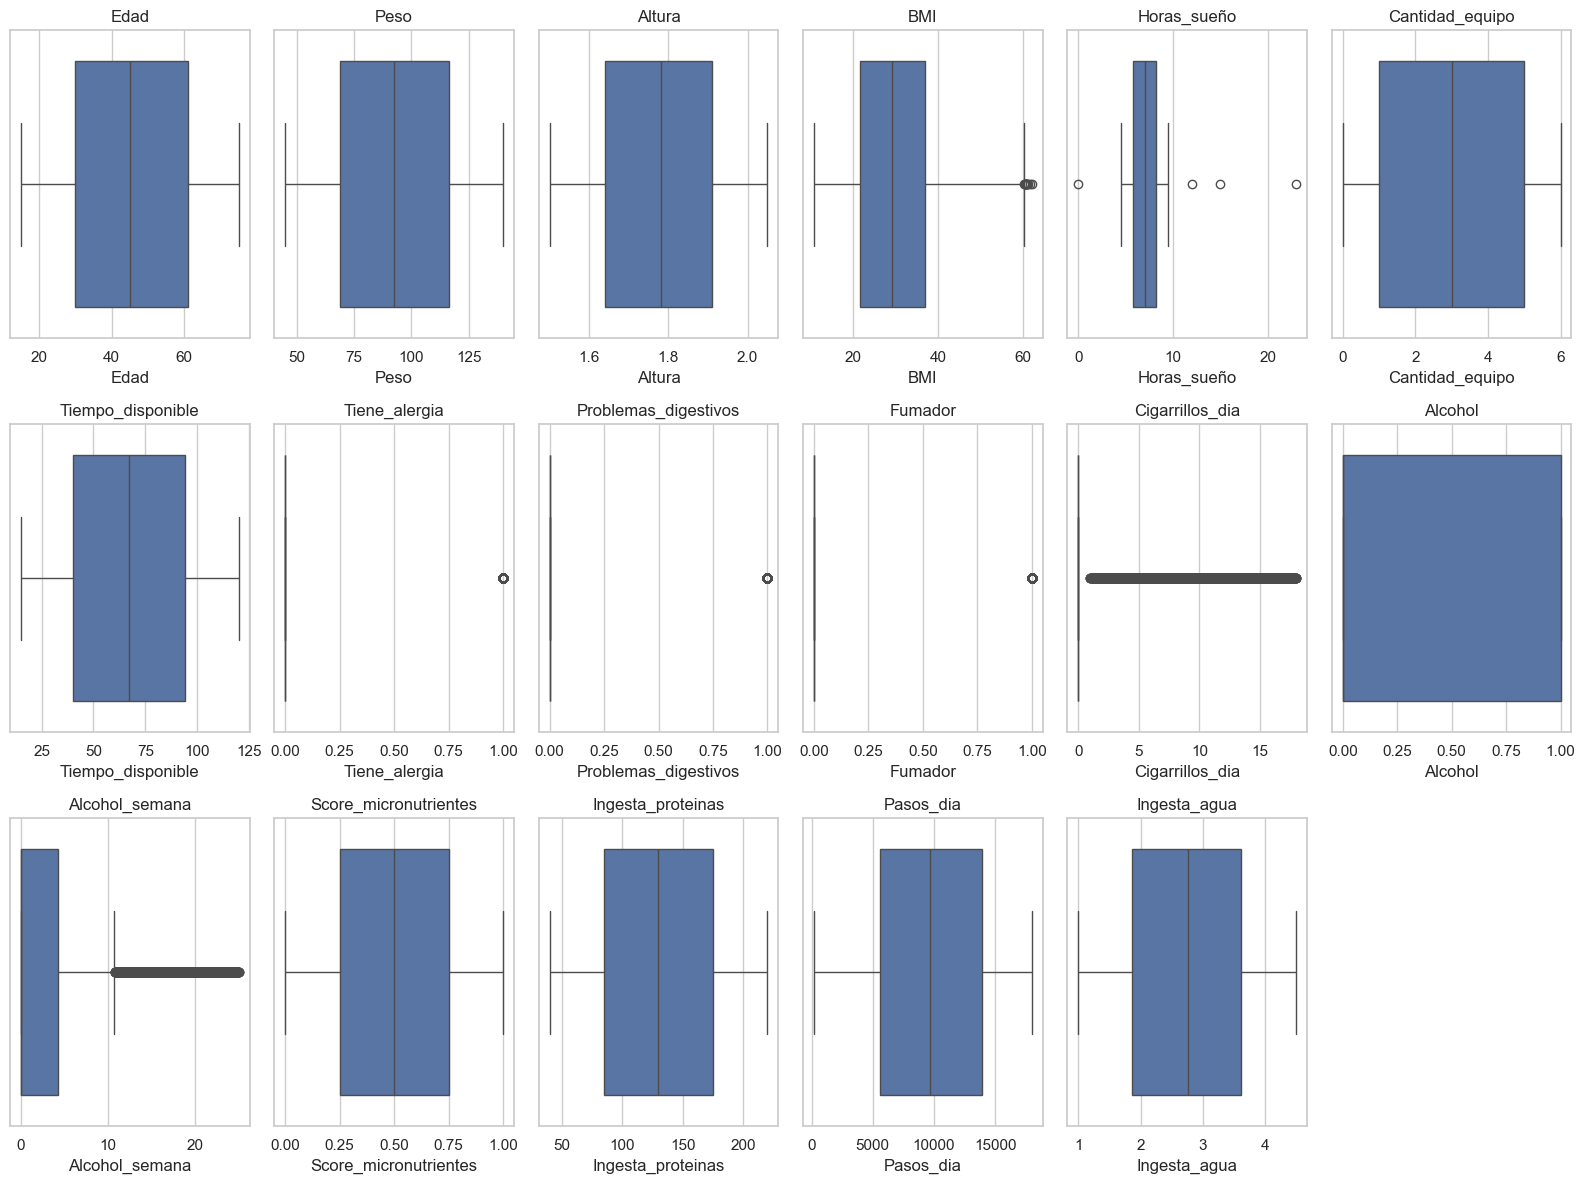

In [34]:
print("\n\n◉ VERIFICAR OUTLIERS:\n")

numericas = df.select_dtypes(include=np.number).columns

col = 6
fil = int(np.ceil(len(numericas) / col))

fig, axes = plt.subplots(fil, col, figsize=(16, 4 * fil))

axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3. Limpieza y preparación de datos:

Con base en los hallazgos del análisis anterior vamos a modificar los datos para luego proceder al modelado.

1. Respecto a la COMPLETITUD podemos notar que hay una muy pequeña cantidad de registros que tienen valores nulos en algunos de sus componentes, solamente 11 datos de "Peso" son nulos por lo que dada la cantidad de datos totales podemos prescindir de ellos.

2. Tambien notamos que entre la mayoría de las variables no hay correlación, sin embargo hay 1 relaciones específicas que puede ser necesario tomar en cuenta:
    - BMI tiene una alta correlacion de mas de 0.8 con "Peso" y una correlación de menos de -0.4 con "Altura". Esto se debe a que BMI es una variable creada matemáticamente a partir de Peso y Altura. Por esto decidimos que la mejor opcion es eliminarla ya que depende directamente de otras 2 variables.

3. Respecto a la UNICIDAD notamos que NO existen registros duplicados por lo que sin una variable específica de "Nombre" o "Id" de cada usuario podemos asumir que todos los datos son de personas distintas.

4. Se analizaron las variables numéricas mediante diagramas de caja con el fin de identificar posibles valores atípicos. No se identificaron valores realmente extremos que indiquen errores o inconsistencias graves.

In [35]:
df = df.dropna(subset=["Peso"])
df = df.drop(columns=["BMI"])

# 4. Construcción del pipeline y division de conjuntos de datos

En esta sección se construye un pipeline de preprocesamiento que permitirá aplicar de manera sistemática y reproducible las transformaciones necesarias sobre los datos antes del entrenamiento de los modelos.

- Las variables numéricas están completas por lo que no requeriran ser imputadas
- Las variables categóricas serán transformadas mediante codificación One-Hot Encoding, permitiendo que los modelos puedan interpretar correctamente las categorías.

Una vez preparados los datos y definido el pipeline de preprocesamiento, se procede a dividir el conjunto de datos en subconjuntos de entrenamiento y prueba con 75% de los datos para entrenamiento y 25% de los datos para prueba.

In [45]:
y_entrenamiento_plan = df["Plan_entrenamiento"]

y_nutricion_plan = df["Plan_nutrición"]

X = df.drop(columns=[
    "Plan_entrenamiento",
    "Plan_nutrición"
])

print(X.shape)
display(X.head())

numericas = X.select_dtypes(include=np.number).columns

categoricas = X.select_dtypes(include="object").columns

print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

print("\nCantidad variables numéricas:", len(numericas))
print("Cantidad variables categóricas:", len(categoricas))

(9687, 23)


,Edad,Gnereo,Peso,Altura,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,...,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
0,60,Masculino,73.7,1.61,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,...,0,0,0,0.0,0,0.0,0.92,182.1,16485,2.49
1,17,Femenino,121.0,1.97,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,...,0,0,0,0.0,0,0.0,0.76,167.7,14256,2.04
2,43,Masculino,110.0,1.52,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,...,0,0,0,0.0,0,0.0,0.34,104.9,3050,2.53
3,49,Otro,73.6,1.96,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,...,0,0,0,0.0,0,0.0,0.71,59.5,2264,3.36
4,53,Femenino,80.8,1.76,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,...,0,1,1,8.7,0,0.0,0.98,51.1,12774,1.90


Variables numéricas:
Index(['Edad', 'Peso', 'Altura', 'Horas_sueño', 'Cantidad_equipo',
       'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador',
       'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes',
       'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua'],
      dtype='object')

Variables categóricas:
Index(['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
       'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido'],
      dtype='object')

Cantidad variables numéricas: 16
Cantidad variables categóricas: 7


In [48]:
pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

pipeline_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", pipeline_numerico, numericas),
    ("cat", pipeline_categorico, categoricas)
])

pipeline_base = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression())
])

DIVISION DE CONJUNTOS DE DATOS RESPECTIVAMENTE:
1. PLAN DE ENTRENAMIENTO
2. PLAN DE NUTRICIÓN

In [46]:
X_train_ent, X_test_ent, y_train_ent, y_test_ent = train_test_split(
    X,
    y_entrenamiento_plan,
    test_size=0.25,
    random_state=42,
    stratify=y_entrenamiento_plan
)

In [47]:
X_train_nut, X_test_nut, y_train_nut, y_test_nut = train_test_split(
    X,
    y_nutricion_plan,
    test_size=0.25,
    random_state=42,
    stratify=y_nutricion_plan
)

# 6. Modelo de regresión logística para la predicción del plan de entrenamiento

En esta sección se construye un modelo de regresión logística para predecir la variable Plan_entrenamiento.

In [ ]:
pipeline_regresionlog_entrenamiento = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000))
])

#FALTA DEFINIR HIPERPARAMETROS TERMINAR MODELO ETC... TENGA EN CUENTA LOS NOMBRES DE LAS VARIABLES PARA ENTRENAMIENTO QUE YA DEFINI ARRIBA

# 7. Modelo de regresión logística para la predicción del plan de nutrición

En esta sección se construye un segundo modelo de regresión logística, enfocado en la predicción de la variable Plan_nutrición.

In [ ]:
pipeline_regresionlog_nutricion = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000))
])

parametros_log = {
    "modelo__penalty": ["l1", "l2"],
    "modelo__solver": ["liblinear", "saga"]
}

# 8. Modelo basado en árboles de decisión para la predicción del plan de entrenamiento

En esta sección se construye un modelo basado en árboles de decisión para la predicción de la variable Plan_entrenamiento.

In [ ]:
pipeline_arbol_entrenamiento = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", DecisionTreeClassifier())
])

#AQUI LE FALTA DEFINIR HIPERPARAMETROS TERMINAR MODELO ETC...

# 9. Modelo basado en árboles de decisión para la predicción del plan de nutrición

En esta sección se desarrolla un modelo basado en árboles de decisión para predecir la variable Plan_nutrición.

In [ ]:
pipeline_arbol_entrenamiento = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", DecisionTreeClassifier())
])

parametros_arbol = {
    "modelo__max_depth": [5, 10, 20],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__criterion": ["gini", "entropy"]
}

# 10. Tabla comparativa de modelos

Analizamos el rendimiento sobre test de los mejores dos modelos, por cada objetivo, obtenidos en los puntos 3 y 4, con base en las métricas recall, precisión y F1-score.

# 11. Identificación de variables más relevantes

En esta sección se analiza la importancia de las variables utilizadas en los modelos, con el fin de identificar qué características influyen en mayor medida en las predicciones realizadas.

Para el modelo basado en árboles de decisión, se utilizará la métrica de importancia de características (**feature_importances_**), que indica la contribución relativa de cada variable en la construcción del árbol.

Por otro lado, en el modelo de regresión logística se analizarán los coeficientes asociados a cada variable, los cuales reflejan el impacto de cada característica en la probabilidad de pertenencia a una clase.

Posteriormente, se compararán los resultados obtenidos entre ambos modelos, lo que permitirá analizar cómo distintos enfoques resaltan diferentes factores del perfil de los usuarios.

# 12. Generación de predicciones sobre datos no etiquetados

En esta sección se utilizará el mejor modelo seleccionado previamente para generar predicciones sobre el conjunto de datos de prueba proporcionado.
Una vez obtenidas las predicciones, se integrarán en el archivo original y se exportarán en formato CSV, siguiendo el formato requerido para la entrega final.

# 13. Análisis de resultados

- ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?

- ¿Existen variables que podrían ser redundantes o poco informativas?

- ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?

- A partir de alguno de los modelos creados con árboles de decisión, describa en términos de reglas, las características que cumplen las variables involucradas en la recomendación que se da. Incluya además, la utilidad y la limitación que tienen este estilo de reglas en modelos de árboles de decisión principalmente en el proceso de explicabilidad del modelo.

- ¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?

- ¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?

- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?